In [1]:
import pandas as pd
import numpy as np

df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_sites_qc_btm = df_sites_qc.iloc[[x=='BTM' for x in site_depth],:]
df_sites_qc_btm = df_sites_qc_btm.loc[:,df_sites_qc_btm.sum()>0]


In [2]:
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v4.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]

df_env = df_env.iloc[:,np.append(range(0,28), range(56,61))]
df_env = df_env.drop(['TKN_pct'], axis=1)


In [3]:
df_env['Total_Carb'] = np.log10(df_env['Total_Carb']+1)
df_env['Total_Nitr'] = np.log10(df_env['Total_Nitr']+1)
df_env['C_to_N_rat'] = np.log10(df_env['C_to_N_rat']+1)

In [4]:
df_env_top = df_env.loc[df_sites_qc_top.index.values,:]
df_env_btm = df_env.loc[df_sites_qc_btm.index.values,:]

df_env_top_pred = df_env_top.iloc[:,np.append(range(0,21), range(24,32))]
df_env_top_pred = df_env_top_pred.fillna(0.)
df_env_btm_pred = df_env_btm.iloc[:,np.append(range(0,21), range(24,32))]
df_env_btm_pred = df_env_btm.fillna(0.)

In [5]:
df_env_top_pred = df_env_top_pred.loc[:,['mean_GWC', 'Mn_mg_per_','CEC_Meq_pe',  'Total_Nitr','Total_Carb']]
df_env_btm_pred = df_env_btm_pred.loc[:,['mean_GWC', 'Mg_Meq_per','Total_Base', 'CEC_Meq_pe',  'Total_Nitr','Total_Carb']]

In [6]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X, y = df_env_top_pred.values, np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [8]:
np.savetxt("top_env_train.csv", X_train, delimiter=',')
np.savetxt("top_resp_train.csv", y_train, delimiter=',')
np.savetxt("top_env_test.csv", X_test, delimiter=',')
np.savetxt("top_resp_test.csv", y_test, delimiter=',')

In [1]:
import joblib
rsh=joblib.load('/home/shic892/corems/gradient_env_5_top_respiration_log_vnnn.pkl')
adj_r2 = rsh.best_estimator_.score(X,y)*(len(y)-1)/(len(y)-X.shape[1]-1)
adj_r2

NameError: name 'X' is not defined

In [2]:
import joblib
rsh=joblib.load('/home/shic892/corems/gradient_env_5_top_respiration_log_vnnn.pkl')
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.0009419401302099844, learning_rate=0.01,
                          loss='huber', max_depth=31, max_features=1,
                          min_samples_split=6, n_estimators=1213,
                          random_state=RandomState(MT19937) at 0x2AE07C08BEB8)

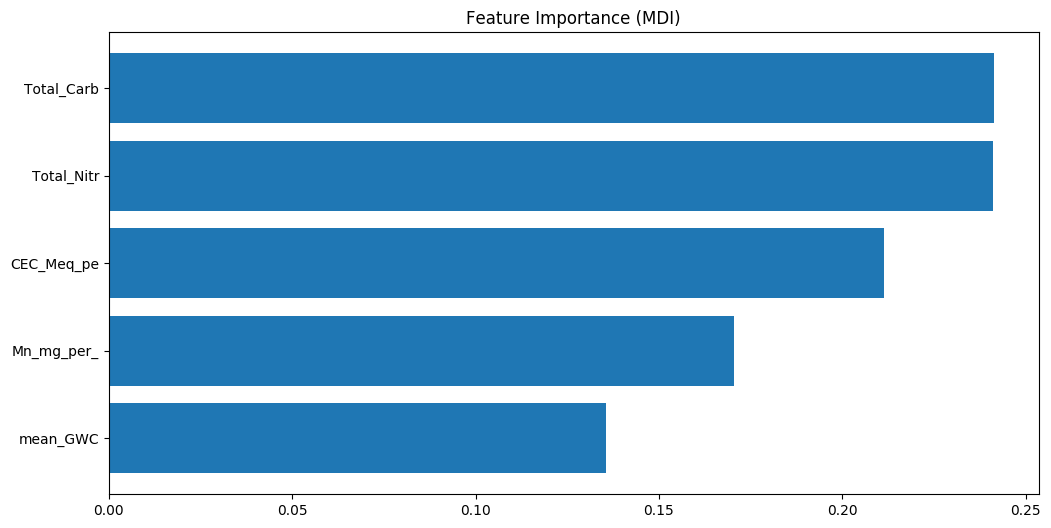

In [8]:
import joblib
rsh=joblib.load('/home/shic892/corems/gradient_env_5_top_respiration_log_vnnn.pkl')

feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_top_pred.iloc[:,0:15].columns)[sorted_idx])
plt.title("Feature Importance (MDI)")
#plt.savefig('1000s_env5_grd_bst_respir_log.pdf',format='pdf')

In [11]:
import joblib
rsh=joblib.load('/home/shic892/corems/gradient_env_6_btm_respiration_log_v1.pkl')
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.017319573463479263,
                          criterion='squared_error', learning_rate=0.01,
                          loss='absolute_error', max_depth=58,
                          max_features='auto', min_samples_split=6,
                          n_estimators=1722,
                          random_state=RandomState(MT19937) at 0x2AE07F3C2048)

In [12]:
rsh.best_score_

-0.5992343754759692

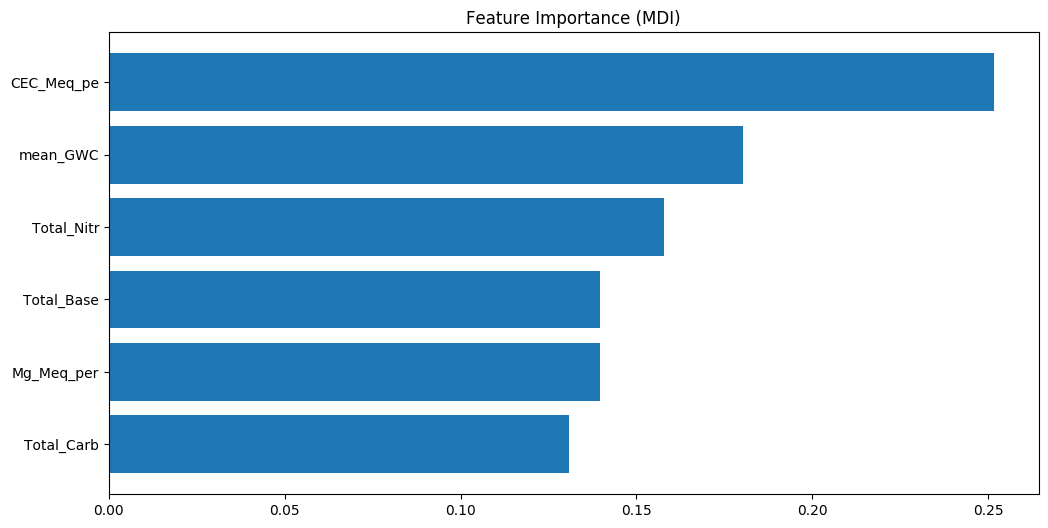

In [9]:
rsh=joblib.load('/home/shic892/corems/gradient_env_6_btm_respiration_log_v1.pkl')

feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_btm_pred.iloc[:,0:15].columns)[sorted_idx])
plt.title("Feature Importance (MDI)")
plt.savefig('1000s_btm_env6_grd_bst_respir_log.pdf',format='pdf')



In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error', 'huber'],
    "n_estimators": randint(50,2000),
    "max_depth": randint(5,63),
    "max_features": ['auto', 'sqrt', 'log2', 1,2,3,4,5],
    "min_samples_split": randint(2, 10),
    "criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.1)
}

rsh = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=1000,return_train_score=True, 
     cv=5, scoring="neg_root_mean_squared_error", 
)
rsh.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B45B7399150),
                   n_iter=1000,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b45b72f0240>,
                                        'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_err...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b45b73254a8>,
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         1, 2, 3, 4, 5],
        

Text(0, 0.5, 'predicted')

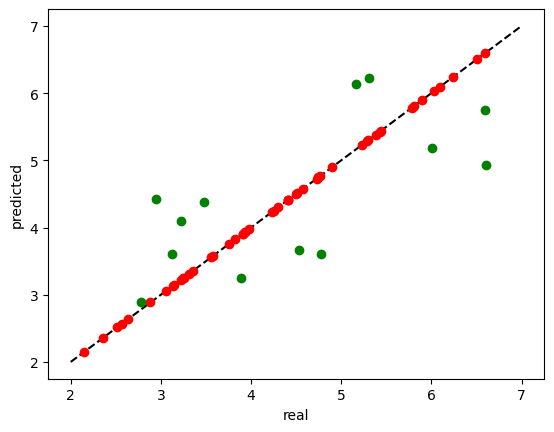

In [20]:
from matplotlib import pyplot as plt


plt.plot([2, 7], [2, 7], 'k--')
plt.plot(    y_train,     rsh.best_estimator_.predict(X_train[:,0:15]),     c="r",     marker='o', linewidth=0 )
plt.plot( y_test,    rsh.best_estimator_.predict(X_test[:,0:15]),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [10]:
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.004355064417148414, learning_rate=0.01,
                          loss='huber', max_depth=14, max_features=1,
                          min_samples_split=5, n_estimators=914,
                          random_state=RandomState(MT19937) at 0x2B45B291CBA0)

In [21]:
rsh.best_estimator_.score(X_test,y_test)

0.4436367977768777

In [22]:
rsh.best_estimator_.score(X_train,y_train)

0.9999999995240748

Text(0.5, 1.0, 'Feature Importance (MDI)')

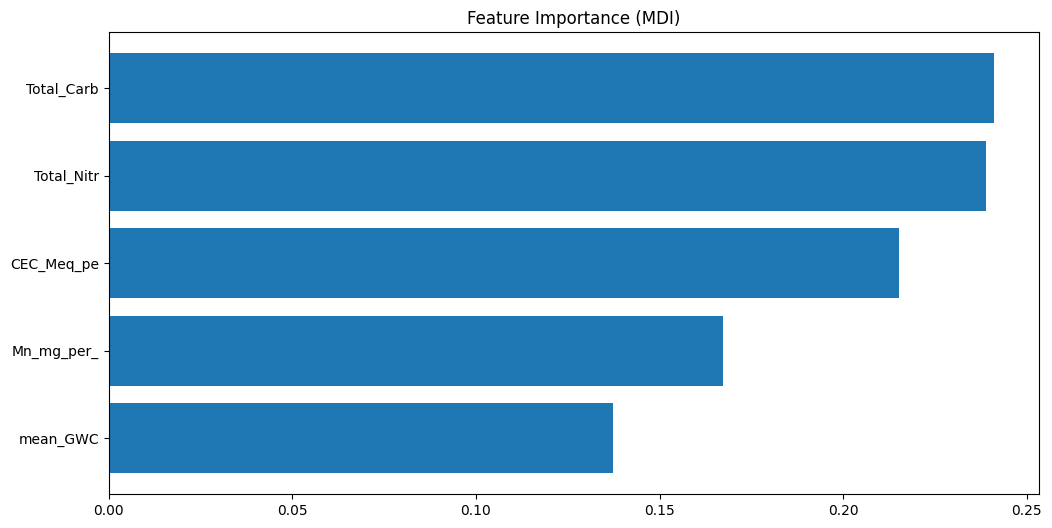

In [11]:
feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_top_pred.iloc[:,0:15].columns)[sorted_idx])
plt.title("Feature Importance (MDI)")

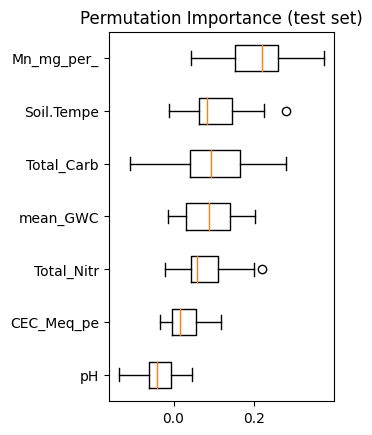

In [100]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh.best_estimator_, X_test[:,0:15], y_test, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(df_env_top_pred.iloc[:,0:15].columns)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

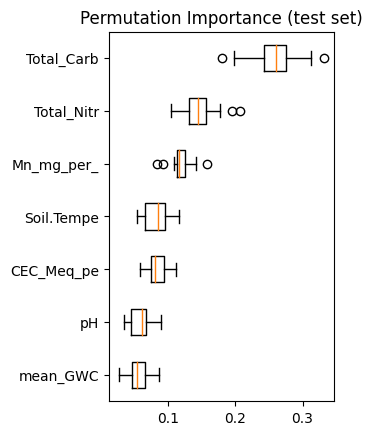

In [99]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh.best_estimator_, X_train[:,0:15], y_train, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(df_env_top_pred.iloc[:,0:15].columns)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

In [7]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [8]:
df_env_top_pred[['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']] = np.log(datah7.T+1)
X, y = df_env_top_pred.values, np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

In [10]:
np.savetxt("top_env_nmf_train.csv", X_train, delimiter=',')
np.savetxt("top_env_nmf_test.csv", X_test, delimiter=',')

In [14]:
rsh = joblib.load('/home/shic892/corems/gradient_nmf_log_top_respiration_log.pkl')
adj_r2 = rsh.best_estimator_.score(np.log(datah7.T+1),y)*(len(y)-1)/(len(y)-7-1)
adj_r2

0.9301527708656055

In [15]:
rsh=joblib.load('/home/shic892/corems/gradient_env_5_nmf_7_log_top_respiration_log_v1.pkl')
adj_r2 = rsh.best_estimator_.score(X,y)*(len(y)-1)/(len(y)-12-1)
adj_r2

1.1189017477713987

In [13]:
rsh=joblib.load('/home/shic892/corems/gradient_env_5_nmf_7_log_top_respiration_log_v1.pkl')
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=1.8673136572547703e-05,
                          criterion='squared_error', loss='huber', max_depth=40,
                          max_features='log2', min_samples_split=7,
                          n_estimators=1392,
                          random_state=RandomState(MT19937) at 0x2AE07F3C2258)

In [14]:
rsh=joblib.load('/home/shic892/corems/gradient_env_6_nmf_5_log_btm_respiration_log_v1_final.pkl')
rsh.best_estimator_


GradientBoostingRegressor(ccp_alpha=0.0006595324507542438,
                          criterion='squared_error', max_depth=16,
                          max_features=7, min_samples_split=9, n_estimators=351,
                          random_state=RandomState(MT19937) at 0x2AE07F3C2678)

In [16]:
rsh=joblib.load('/home/shic892/corems/gradient_nmf_log_top_respiration_log.pkl')
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.043552484980481455,
                          criterion='squared_error', loss='absolute_error',
                          max_depth=14, max_features=2, min_samples_split=4,
                          n_estimators=422,
                          random_state=RandomState(MT19937) at 0x2AE07F3C2888)

In [17]:
rsh=joblib.load('/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd8_best.pkl')
rsh.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.0017787676080722834, learning_rate=0.001,
                          max_depth=7, min_samples_leaf=7, min_samples_split=6,
                          n_estimators=636,
                          random_state=RandomState(MT19937) at 0x2AE07F3C2BA0)

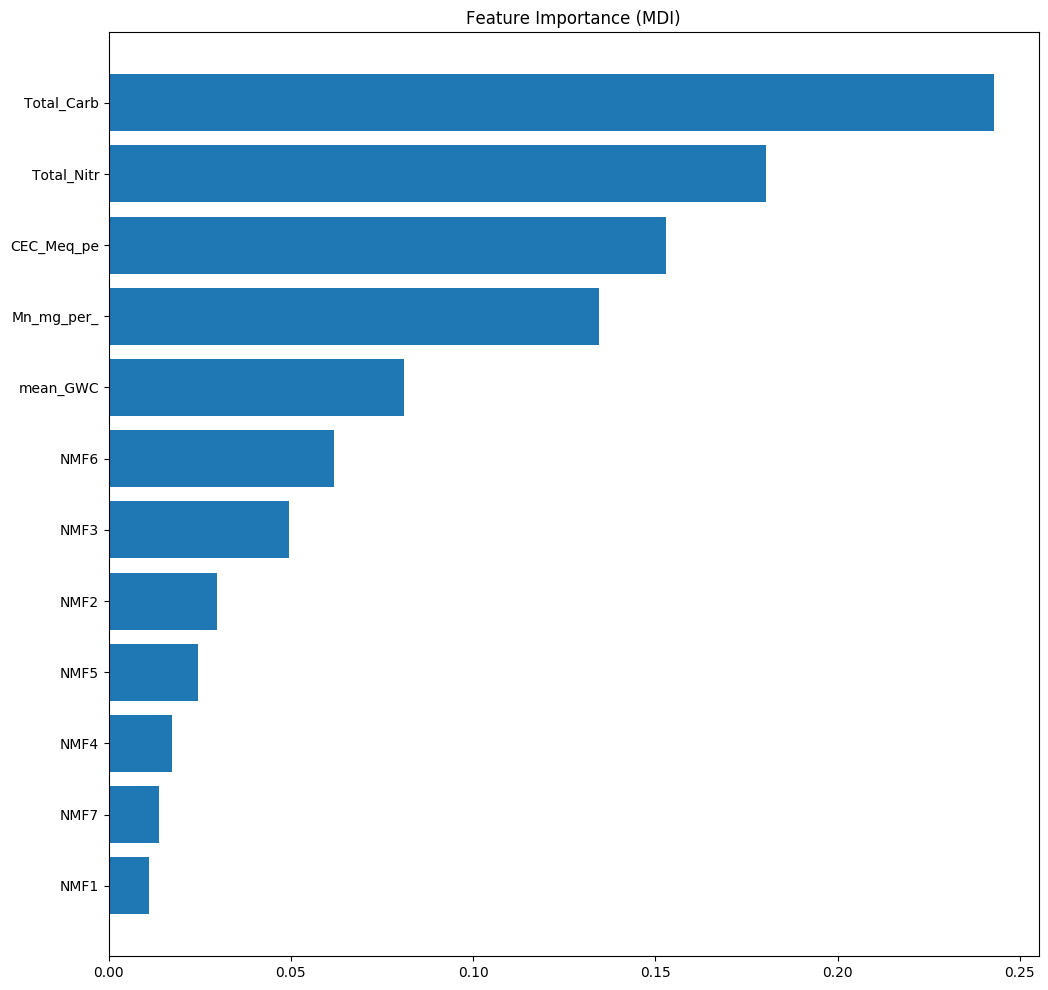

In [16]:
rsh=joblib.load('/home/shic892/corems/gradient_env_5_nmf_7_log_top_respiration_log_v1.pkl')

feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 12))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_top_pred.iloc[:,0:15].columns)[sorted_idx])
plt.title("Feature Importance (MDI)")
plt.savefig('1000s_top_env5_nmf7_grd_bst_respir_log.pdf',format='pdf')


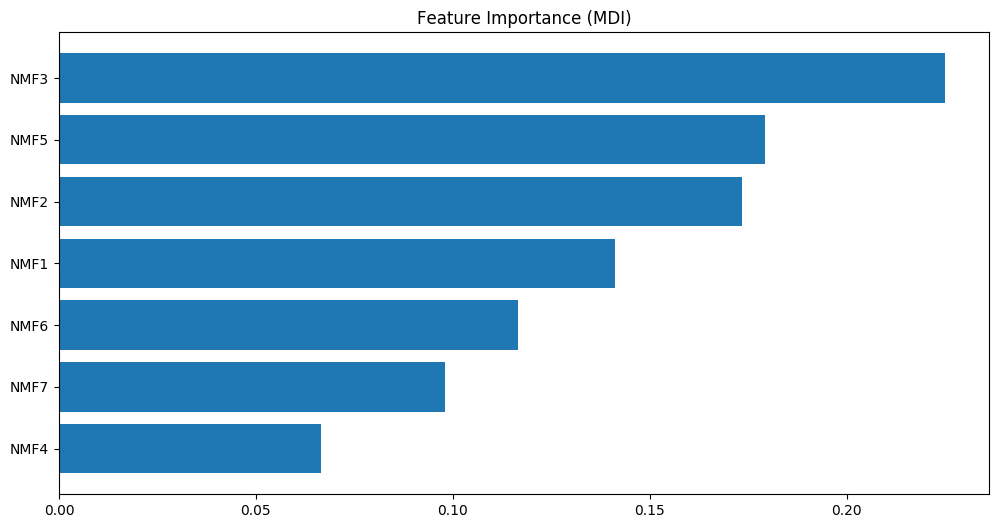

In [15]:
rsh = joblib.load('/home/shic892/corems/gradient_nmf_log_top_respiration_log.pkl')


feature_importance = rsh.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")

plt.yticks(pos, np.array(['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7'])[sorted_idx])
plt.title("Feature Importance (MDI)")
plt.savefig('1000s_top_nmf7_grd_bst_respir_log.pdf',format='pdf')

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error', 'huber'],
    "n_estimators": randint(50,2000),
    "max_depth": randint(5,63),
    "max_features": ['auto', 'sqrt', 'log2',3,4,5,6,7,8,9,10,11,12],
    "min_samples_split": randint(2, 10),
    "criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.1)
}

rsh3 = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=500,return_train_score=True, 
     cv=5, scoring="neg_root_mean_squared_error", 
)
rsh3.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B45B7399258),
                   n_iter=500,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b45b711dd30>,
                                        'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_erro...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b45b711d898>,
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         3, 4, 5, 6, 7, 8, 9,
   

Text(0, 0.5, 'predicted')

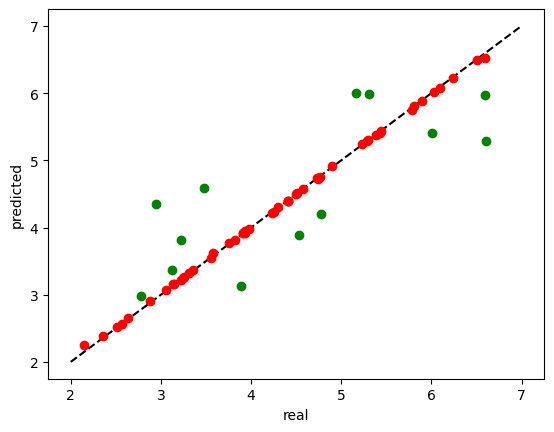

In [25]:

plt.plot([2, 7], [2, 7], 'k--')
plt.plot(    y_train,     rsh3.best_estimator_.predict(X_train),     c="r",     marker='o', linewidth=0 )
plt.plot(y_test,    rsh3.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [107]:
rsh3.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.007167538992643917,
                          criterion='squared_error', loss='huber', max_depth=31,
                          max_features='log2', min_samples_split=6,
                          n_estimators=1845,
                          random_state=RandomState(MT19937) at 0x2B47F076C468)

In [26]:
rsh3.best_estimator_.score(X_test,y_test)

0.6170027585671154

Text(0.5, 1.0, 'Feature Importance (MDI)')

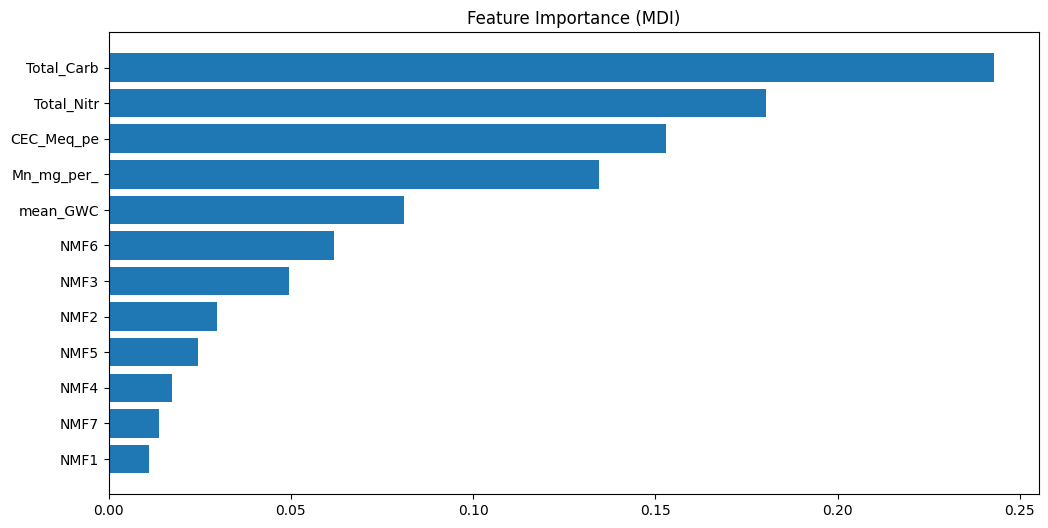

In [27]:
feature_importance = rsh3.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_top_pred.columns)[sorted_idx])
plt.title("Feature Importance (MDI)")

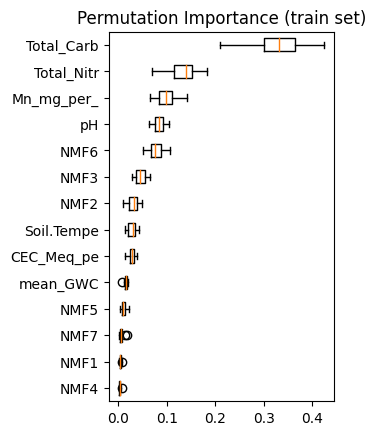

In [112]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh3.best_estimator_, X_train, y_train, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(df_env_top_pred.columns)[sorted_idx],
)
plt.title("Permutation Importance (train set)")
fig.tight_layout()
plt.show()

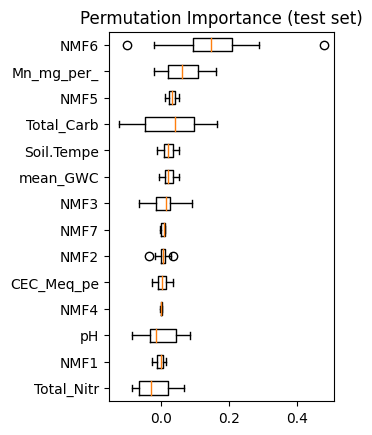

In [113]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh3.best_estimator_, X_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(df_env_top_pred.columns)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

In [28]:
import joblib
joblib.dump(rsh, '/home/shic892/corems/gradient_env_5_top_respiration_log_v1.pkl')
joblib.dump(rsh3, '/home/shic892/corems/gradient_env_5_nmf_7_log_top_respiration_log_v1.pkl')
df_env_top_pred.to_csv('/home/shic892/corems/env_5_nmf_top_resp_pred.csv')

In [11]:
X, y = df_env_btm_pred.values, np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [12]:
np.savetxt("btm_env_train.csv", X_train, delimiter=',')
np.savetxt("btm_resp_train.csv", y_train, delimiter=',')
np.savetxt("btm_env_test.csv", X_test, delimiter=',')
np.savetxt("btm_resp_test.csv", y_test, delimiter=',')

In [17]:
rsh=joblib.load('/home/shic892/corems/gradient_env_6_btm_respiration_log_v1.pkl')
adj_r2 = rsh.best_estimator_.score(X,y)*(len(y)-1)/(len(y)-6-1)
adj_r2

0.9771268805841898

In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error', 'huber'],
    "n_estimators": randint(50,2000),
    "max_depth": randint(5,63),
    "max_features": ['auto', 'sqrt', 'log2',2,3,4,5],
    "min_samples_split": randint(2, 10),
    "criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.01)
}

rsh_btm = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=1000,return_train_score=True, 
     cv=5, scoring="neg_root_mean_squared_error", 
)
rsh_btm.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B2BA8D0F150),
                   n_iter=1000,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b2ba90f5d68>,
                                        'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_err...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b2ba90f59e8>,
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         2, 3, 4, 5],
           

Text(0, 0.5, 'predicted')

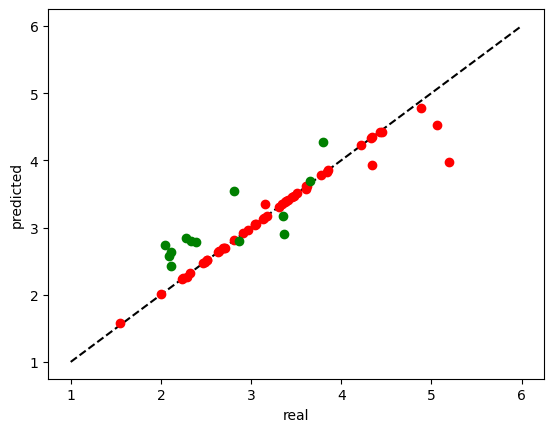

In [23]:
import matplotlib.pyplot as plt
plt.plot([1, 6], [1, 6], 'k--')
plt.plot(    y_train,     rsh_btm.best_estimator_.predict(X_train),     c="r",     marker='o', linewidth=0 )
plt.plot(y_test,    rsh_btm.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

In [26]:
rsh_btm.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.017319573463479263,
                          criterion='squared_error', learning_rate=0.01,
                          loss='absolute_error', max_depth=58,
                          max_features='auto', min_samples_split=6,
                          n_estimators=1722,
                          random_state=RandomState(MT19937) at 0x2B2BA8D0F468)

Text(0.5, 1.0, 'Feature Importance (MDI)')

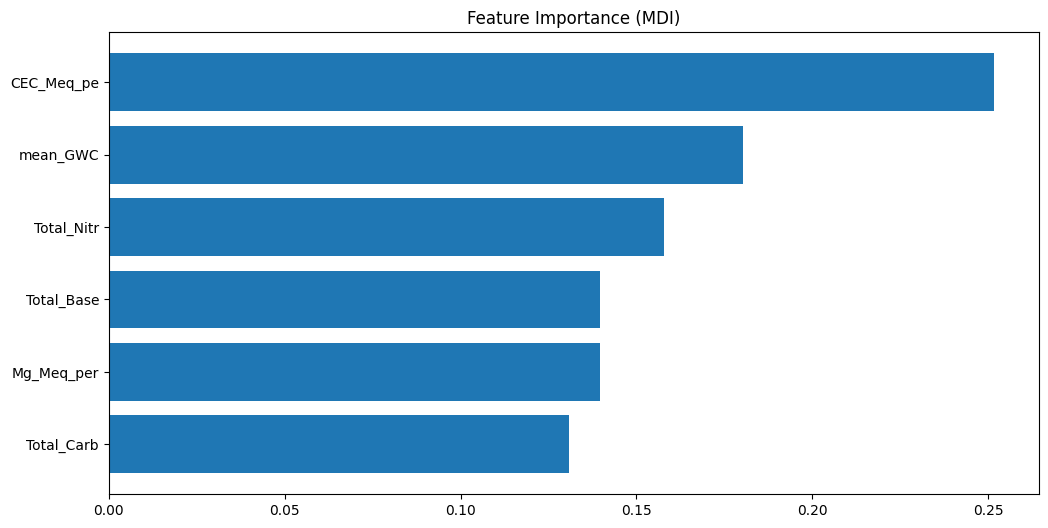

In [25]:
feature_importance = rsh_btm.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_btm_pred.columns)[sorted_idx])
plt.title("Feature Importance (MDI)")

In [24]:
rsh_btm.best_estimator_.score(X_test,y_test)

0.4329745276290242

In [77]:
rsh1.best_estimator_.score(X_train,y_train)

0.7616390562553388

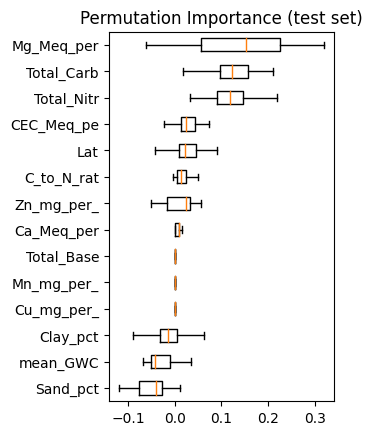

In [75]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh1.best_estimator_, X_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(df_env_btm_pred.columns)[sorted_idx],
)
plt.title("Permutation Importance (test set)")
fig.tight_layout()
plt.show()

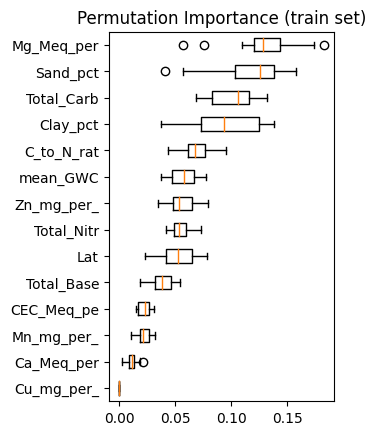

In [76]:
from sklearn.inspection import permutation_importance
result = permutation_importance(
    rsh1.best_estimator_, X_train, y_train, n_repeats=20, random_state=42, n_jobs=2
)
sorted_idx = result.importances_mean.argsort()
plt.subplot(1, 2, 2)
plt.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=np.array(df_env_btm_pred.columns)[sorted_idx],
)
plt.title("Permutation Importance (train set)")
fig.tight_layout()
plt.show()

In [13]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/5/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah5 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah5.shape)

(5, 16)
(5, 15)
(5, 15)
(5, 15)
(5, 61)


In [20]:
rsh = joblib.load('/home/shic892/corems/gradient_5_NMF_log_btm_respiration_log_rmd8_best.pkl')
adj_r2 = rsh.best_estimator_.score(np.log(datah5.T+1),y)*(len(y)-1)/(len(y)-5-1)
adj_r2

0.23450450553584806

In [14]:
df_env_btm_pred[['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']] = np.log(datah5.T+1)
X, y = df_env_btm_pred.values, np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
np.savetxt("btm_env_nmf_train.csv", X_train, delimiter=',')
np.savetxt("btm_env_nmf_test.csv", X_test, delimiter=',')

In [22]:
rsh = joblib.load('/home/shic892/corems/gradient_env_6_nmf_5_log_btm_respiration_log_v1_final.pkl')
adj_r2 = rsh.best_estimator_.score(X,y)*(len(y)-1)/(len(y)-11-1)
adj_r2

1.1171017029764

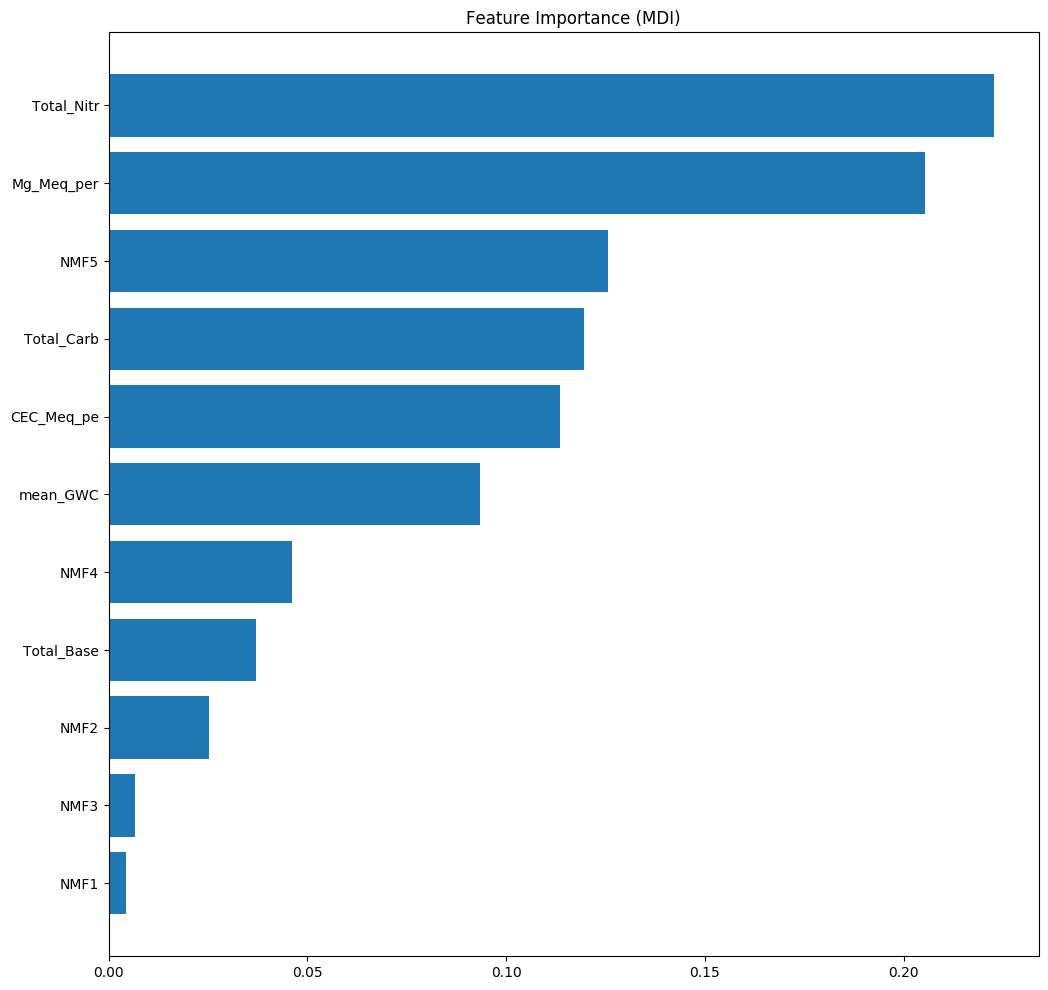

In [20]:
rsh_btm_nmf = joblib.load('/home/shic892/corems/gradient_env_6_nmf_5_log_btm_respiration_log_v1_final.pkl')
feature_importance = rsh_btm_nmf.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 12))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_btm_pred.columns)[sorted_idx])
plt.title("Feature Importance (MDI)")
plt.savefig('1000s_btm_env6_nmf5_grd_bst_respir_log.pdf',format='pdf')

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, expon
rng = np.random.RandomState(0)

clf = GradientBoostingRegressor(random_state=rng)

param_dist = {
    "loss": ['squared_error','absolute_error', 'huber'],
    "n_estimators": randint(50,2000),
    "max_depth": randint(5,60),
    "max_features": ['auto', 'sqrt', 'log2',3,4,5,6,7,8,9,10],
    "min_samples_split": randint(2, 10),
    "criterion": ['friedman_mse', 'squared_error'],
    "learning_rate": [0.0001, 0.001, 0.01, 0.1, 1.0],
    "ccp_alpha" : expon(scale=0.01)
}

rsh_btm_nmf = RandomizedSearchCV(
    estimator=clf, param_distributions=param_dist,random_state=rng, n_iter=500,return_train_score=True, 
     cv=5, scoring="neg_root_mean_squared_error", 
)
rsh_btm_nmf.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(random_state=RandomState(MT19937) at 0x2B2BA4676888),
                   n_iter=500,
                   param_distributions={'ccp_alpha': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b2ba4bb2b70>,
                                        'criterion': ['friedman_mse',
                                                      'squared_error'],
                                        'learning_rate': [0.0001, 0.001, 0.01,
                                                          0.1, 1.0],
                                        'loss': ['squared_error',
                                                 'absolute_erro...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x2b2ba4bb2780>,
                                        'max_features': ['auto', 'sqrt', 'log2',
                                                         3, 4, 5, 6, 7, 8, 9,
   

Text(0, 0.5, 'predicted')

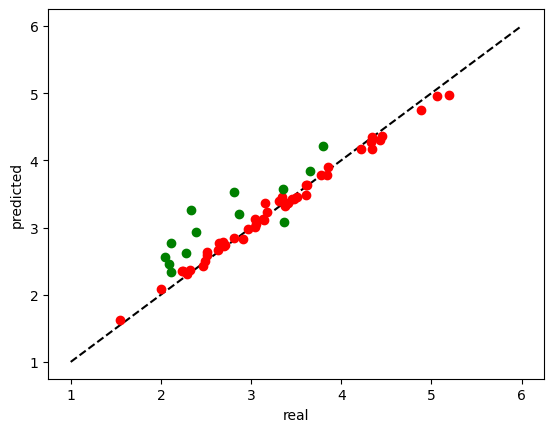

In [14]:
import matplotlib.pyplot as plt
plt.plot([1, 6], [1, 6], 'k--')
plt.plot(    y_train,     rsh_btm_nmf.best_estimator_.predict(X_train),     c="r",     marker='o', linewidth=0 )
plt.plot(y_test,    rsh_btm_nmf.best_estimator_.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

Text(0.5, 1.0, 'Feature Importance (MDI)')

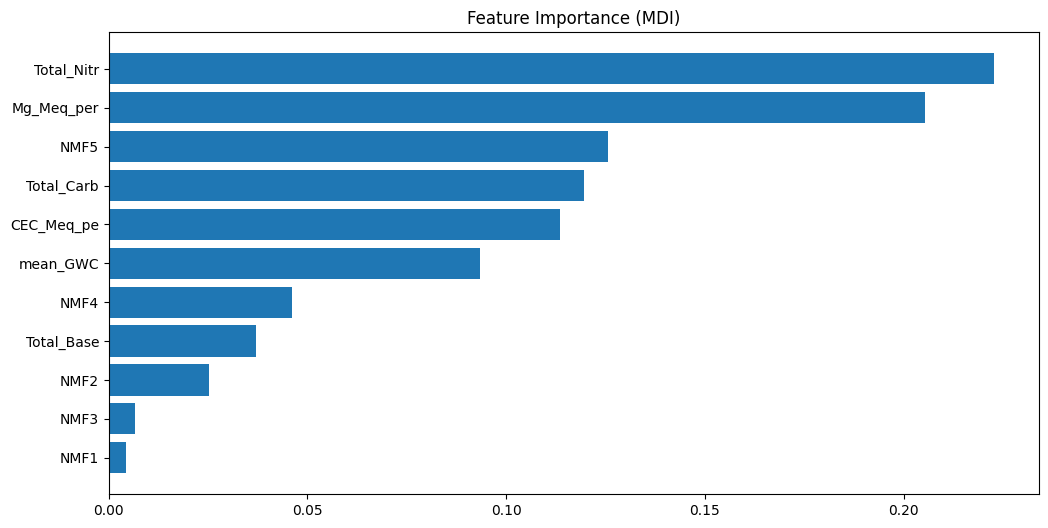

In [18]:
feature_importance = rsh_btm_nmf.best_estimator_.feature_importances_
sorted_idx = np.argsort(feature_importance)
pos = np.arange(sorted_idx.shape[0]) + 0.5
fig = plt.figure(figsize=(12, 6))

plt.barh(pos, feature_importance[sorted_idx], align="center")
plt.yticks(pos, np.array(df_env_btm_pred.columns)[sorted_idx])
plt.title("Feature Importance (MDI)")

In [15]:
rsh_btm_nmf.best_estimator_.score(X_test,y_test)

0.36284296682558537

In [17]:
rsh_btm_nmf.best_estimator_

GradientBoostingRegressor(ccp_alpha=0.0006595324507542438,
                          criterion='squared_error', max_depth=16,
                          max_features=7, min_samples_split=9, n_estimators=351,
                          random_state=RandomState(MT19937) at 0x2B2BA4676BA0)

In [87]:
joblib.dump(rsh1, '/home/shic892/corems/gradient_env_14_top_respiration_log_v0.pkl')
joblib.dump(rsh2, '/home/shic892/corems/gradient_env_14_nmf_5_log_top_respiration_log_v0.pkl')
df_env_btm_pred.to_csv('/home/shic892/corems/env_nmf_btm_resp_pred.csv')

In [27]:
import joblib
joblib.dump(rsh_btm, '/home/shic892/corems/gradient_env_6_btm_respiration_log_v1.pkl')
#joblib.dump(rsh_btm_nmf, '/home/shic892/corems/gradient_env_6_nmf_5_log_btm_respiration_log_v1.pkl')
#df_env_btm_pred.to_csv('/home/shic892/corems/env_6_nmf_btm_resp_pred.csv')

['/home/shic892/corems/gradient_env_6_btm_respiration_log_v1.pkl']